In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import matplotlib

In [2]:


def ANIMATION(data, fps=2, n_rows=None, # paramétere a szimulációnak
			   dpi=100, name='new.gif', # anim mentéshez
				 save=True, # anim mentéshez
				 show=True, # html jegyzetben lejátszható animáció
				 scale=5,   # képszélesség
				 skip_first_frames=0, # hanyadik képkockától animáljon. Az első pár elég unalmas
				 n_rule=4): # paramétere a szimulációnak
	
	if n_rows is None:
		n_rows = len(data[0, :])
	
	
	n_frames = (data.shape[0] // n_rows) - skip_first_frames 
	frames = data[skip_first_frames * n_rows :, :].reshape(n_frames, n_rows, -1)
	print("No of frames:", n_frames)
	
	fig, ax = plt.subplots(figsize=(scale, scale))
	ax = plt.Axes(fig, [0., 0., 1., 1.])
	ax.set_axis_off()
	fig.add_axes(ax)

	c_names = ['peru', 'lightgreen', 'forestgreen', 'darkgreen'][:n_rule]
	c_names.append("red")

	colormap = ListedColormap(c_names)
	norm = matplotlib.colors.Normalize(vmin=0, vmax=n_rule)

	im = ax.imshow(frames[0], cmap=colormap, norm=norm, interpolation='nearest')
	
	def animation_update(i):
		im.set_data(frames[i])
		return [im] 

	ani = FuncAnimation(fig, animation_update, frames=n_frames, blit=True, interval=1000/fps)

	if save:

		ani.save(name, writer='pillow', fps=fps, dpi=dpi)
		
	if show:

		return HTML(ani.to_jshtml())
		
	plt.close(fig)

In [ ]:
scale = 2 # az itt lévő tárgyak és pálya skálázhatóságáért

n_rows, n_cols = 50*scale, 50*scale # szimulációs paraméterek pálya szélesség magasság
n_rule = 2 # legfeljebb 4 lehet, hánynál omoljon/lobbanjon
run_time = 1000 # 10000 nél jó ha kissebb (futási idő)
file_name = "fire"
growth = 20 # Mennyi fa nő egy időlépés alatt

mask = np.zeros((n_rows, n_cols), dtype=int)

# A wall with a gap 
mask[:, 25*scale] = 1
mask[40*scale:45*scale, 25*scale] = 0   # gap

# A circular obstacle 
yy, xx = np.ogrid[:n_rows, :n_cols]
circle = (yy - 15*scale)**2 + (xx - 10*scale)**2 <= (6*scale)**2
mask[circle] = 1

# A rectangular building
mask[5*scale:10*scale, 35*scale:42*scale] = 1

np.savetxt("mask.txt", mask, fmt="%d")

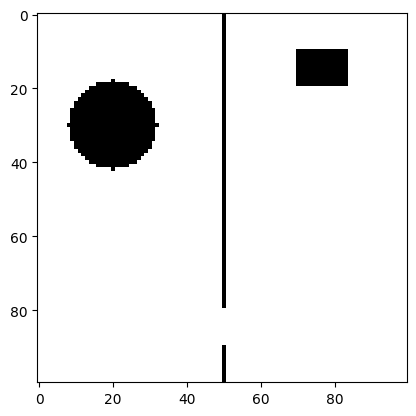

In [4]:
import matplotlib.pyplot as plt
plt.imshow(mask, cmap="gray_r")
plt.show()

In [14]:
# Szimulációt futtató kód hivása pythonból

arguments = ["simulator.exe", str(n_rows), str(n_cols), str(n_rule), str(run_time), file_name, str(growth), "mask.txt"]
subprocess.run(arguments, stdout=subprocess.PIPE)

CompletedProcess(args=['simulator.exe', '100', '100', '4', '1000', 'fire', '20', 'mask.txt'], returncode=0, stdout=b'')

In [15]:
# A kapott adatok betöltése

data_display = np.loadtxt(file_name + ".txt", dtype=int)
data_slipage = np.loadtxt(file_name + "_slipage.txt", dtype=int)

In [16]:
ANIMATION(data_display, fps=30, dpi=100, n_rows=n_rows, name="new_3.gif", save=True, show=False, scale=3, skip_first_frames=0)

No of frames: 7006


Fitted parameters: a=-0.000 ± 0.000, b=-7.238e-02 ± 2.310e+01, c=7.238e-02 ± 2.310e+01, d=1.227e-16 ± 6.569e-03


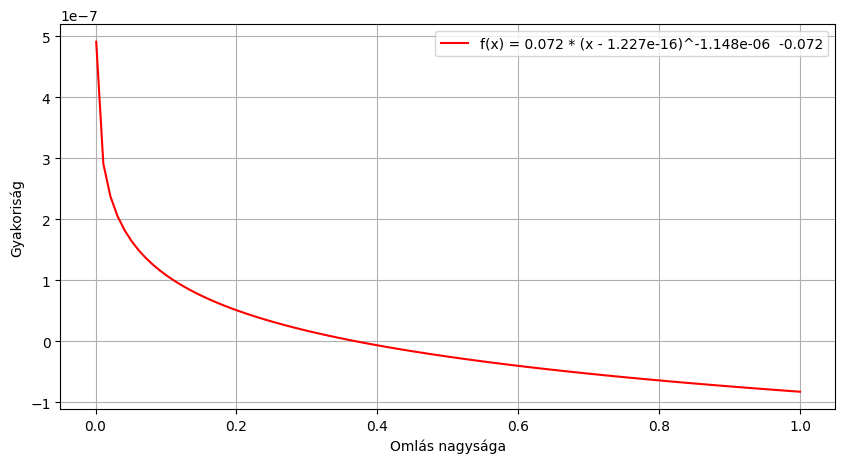

In [ ]:
# Ezt az omlások eloszlásnak vizsgálatára írtam, írhatsz helyette mást

from scipy.optimize import curve_fit

start = 5000
min_val = 0

nonzero_slipage = data_slipage[start:, 1][data_slipage[start:, 1] > min_val]
def func(x, a, b, c, d):
	return c * np.float64(x - d) ** a + b

y, bin_edges = np.histogram(nonzero_slipage, bins=100)
x = 0.5 * (bin_edges[:-1] + bin_edges[1:])
popt, pcov = curve_fit(func, x, y, p0=[-1, 0, 1, 0], bounds=([-2, -1, 0, 0], [0, 1, np.inf, 2]))
perr = np.sqrt(np.diag(pcov))
print(f"Fitted parameters: a={popt[0]:.3f} ± {perr[0]:.3f}, b={popt[1]:.3e} ± {perr[1]:.3e}, c={popt[2]:.3e} ± {perr[2]:.3e}, d={popt[3]:.3e} ± {perr[3]:.3e}")
x_fit = np.linspace(0.001, max(np.max(nonzero_slipage), 1), 100) if len(nonzero_slipage) > 0 else np.linspace(0.001, 1, 100)
y_fit = func(x_fit, *popt)
plt.figure(figsize=(10, 5))

plt.plot(x_fit, y_fit, color='red', label=f'f(x) = {popt[2]:.3f} * (x - {popt[3]:.3e})^{popt[0]:.3e}  {popt[1]:.3f}')


plt.hist(nonzero_slipage, bins=100, color='black', alpha=0.7)
plt.xlabel("Omlás nagysága")
plt.ylabel("Gyakoriság")
plt.legend()
plt.grid()
plt.show()

In [ ]:
print("Fitted parameters:", popt)

Fitted parameters: [-1.14765938e-06 -7.23821666e-02  7.23820839e-02  1.22739811e-16]
